# Dimensionality Reduction & Unsupervised Clustering

## Objective

This notebook applies Principal Component Analysis (PCA) and unsupervised clustering techniques to high-dimensional smartphone sensor data.

The analysis includes:

- Data preprocessing and standardization
- Principal Component Analysis (PCA)
- Explained variance and scree plot analysis
- K-Means clustering
- Elbow Method
- Silhouette Score analysis
- DBSCAN clustering
- Hierarchical clustering
- 2D and 3D cluster visualization
- Comparison of clustering approaches

## Dataset

Human Activity Recognition Using Smartphones

Source: UCI Machine Learning Repository

The dataset contains 10,299 observations and 561 numerical features.

The activity labels are not used as input to the unsupervised clustering algorithms. They may be used later for post-hoc interpretation of the discovered clusters.

In [8]:
from pathlib import Path
import pandas as pd

# Define dataset path
DATA_DIR = Path("../data/raw/UCI HAR Dataset")

# Load feature names
features = pd.read_csv(
    DATA_DIR / "features.txt",
    sep=r"\s+",
    header=None,
    names=["index", "feature"]
)

# Load activity labels
activity_labels = pd.read_csv(
    DATA_DIR / "activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["activity_id", "activity"]
)

# Load training and testing feature data
X_train = pd.read_csv(
    DATA_DIR / "train" / "X_train.txt",
    sep=r"\s+",
    header=None
)

X_test = pd.read_csv(
    DATA_DIR / "test" / "X_test.txt",
    sep=r"\s+",
    header=None
)

# Assign feature names
X_train.columns = features["feature"]
X_test.columns = features["feature"]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Number of features:", len(features))
print("\nActivity labels:")
print(activity_labels)

Training data shape: (7352, 561)
Testing data shape: (2947, 561)
Number of features: 561

Activity labels:
   activity_id            activity
0            1             WALKING
1            2    WALKING_UPSTAIRS
2            3  WALKING_DOWNSTAIRS
3            4             SITTING
4            5            STANDING
5            6              LAYING


In [9]:
# Basic data quality inspection

print("Missing values in training data:", X_train.isna().sum().sum())
print("Missing values in testing data:", X_test.isna().sum().sum())

print("\nFirst 5 feature names:")
print(features["feature"].head())

print("\nFirst 5 rows of training data:")
display(X_train.head())

Missing values in training data: 0
Missing values in testing data: 0

First 5 feature names:
0    tBodyAcc-mean()-X
1    tBodyAcc-mean()-Y
2    tBodyAcc-mean()-Z
3     tBodyAcc-std()-X
4     tBodyAcc-std()-Y
Name: feature, dtype: str

First 5 rows of training data:


feature,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [10]:
# Data quality and consistency checks

print("=== DATA QUALITY CHECKS ===")

# 1. Shape consistency
print("\n1. Shape consistency")
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Feature count matches:", X_train.shape[1] == X_test.shape[1])

# 2. Missing values
print("\n2. Missing values")
print("Training:", X_train.isna().sum().sum())
print("Testing:", X_test.isna().sum().sum())

# 3. Duplicate feature names
print("\n3. Duplicate feature names")
print("Duplicate feature names:", features["feature"].duplicated().sum())

# 4. Data types
print("\n4. Data types")
print("Non-numeric training columns:",
      X_train.select_dtypes(exclude="number").shape[1])

# 5. Constant features
print("\n5. Constant features")
constant_features = X_train.columns[X_train.nunique() <= 1]
print("Number of constant features:", len(constant_features))

# 6. Feature name consistency
print("\n6. Feature name consistency")
print("Train/Test column names match:",
      X_train.columns.equals(X_test.columns))

# Final validation
assert X_train.shape[1] == 561
assert X_test.shape[1] == 561
assert X_train.columns.equals(X_test.columns)
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print("\n✓ All core validation checks passed.")

=== DATA QUALITY CHECKS ===

1. Shape consistency
Training features: (7352, 561)
Testing features: (2947, 561)
Feature count matches: True

2. Missing values
Training: 0
Testing: 0

3. Duplicate feature names
Duplicate feature names: 84

4. Data types
Non-numeric training columns: 0

5. Constant features
Number of constant features: 0

6. Feature name consistency
Train/Test column names match: True

✓ All core validation checks passed.


In [12]:
# Make feature names unique while preserving all 561 features
original_feature_names = features["feature"].tolist()

unique_feature_names = pd.Series(original_feature_names).astype(str)

# Add suffixes to duplicated names
seen = {}
final_feature_names = []

for name in unique_feature_names:
    if name not in seen:
        seen[name] = 0
        final_feature_names.append(name)
    else:
        seen[name] += 1
        final_feature_names.append(f"{name}__dup{seen[name]}")

X_train.columns = final_feature_names
X_test.columns = final_feature_names

print("Original feature count:", len(original_feature_names))
print("Final feature count:", len(final_feature_names))
print("Duplicate column names after renaming:",
      X_train.columns.duplicated().sum())

Original feature count: 561
Final feature count: 561
Duplicate column names after renaming: 0


In [13]:
from sklearn.preprocessing import StandardScaler

# Standardize using training data only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

print("\nTraining mean (approx.):", X_train_scaled.mean())
print("Training standard deviation (approx.):", X_train_scaled.std())

Training scaled shape: (7352, 561)
Testing scaled shape: (2947, 561)

Training mean (approx.): 1.1804271735699034e-17
Training standard deviation (approx.): 1.0


In [14]:
from sklearn.decomposition import PCA

# Fit PCA on the standardized training data
pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of principal components:", X_train_pca.shape[1])
print("PCA output shape:", X_train_pca.shape)

Original number of features: 561
Number of principal components: 561
PCA output shape: (7352, 561)


In [16]:
# Inspect explained variance

explained_variance = pca.explained_variance_ratio_

print("Total explained variance:", explained_variance.sum())
print("First 10 components:")
print(explained_variance[:10])

Total explained variance: 0.9999999999999997
First 10 components:
[0.50781172 0.0658068  0.02806437 0.02503953 0.01888285 0.01724006
 0.01371011 0.01199078 0.0099586  0.00965087]


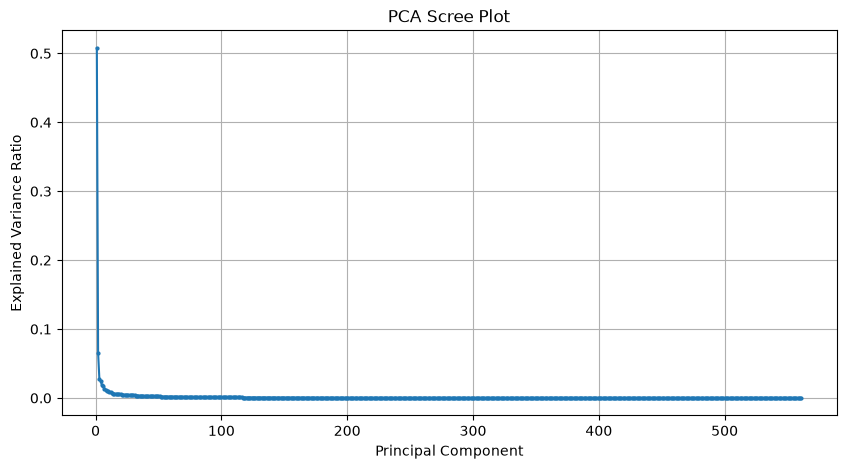

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot explained variance ratio
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o",
    markersize=2
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.show()

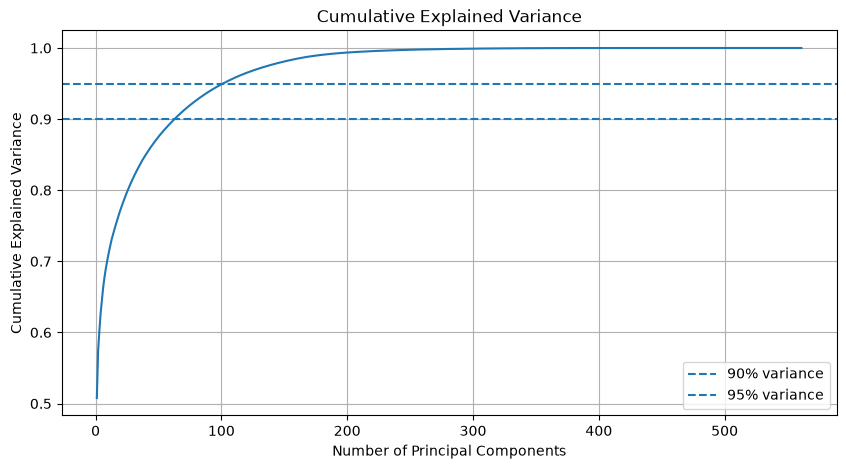

In [18]:
# Plot cumulative explained variance

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(y=0.90, linestyle="--", label="90% variance")
plt.axhline(y=0.95, linestyle="--", label="95% variance")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Determine components required for common variance thresholds

components_90 = np.argmax(cumulative_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components required for 90% variance:", components_90)
print("Components required for 95% variance:", components_95)

Components required for 90% variance: 63
Components required for 95% variance: 102


In [20]:
# Select PCA components retaining approximately 95% variance

n_components = components_95

X_train_pca_reduced = X_train_pca[:, :n_components]

# Transform test data using the already-fitted PCA model
X_test_pca = pca.transform(X_test_scaled)
X_test_pca_reduced = X_test_pca[:, :n_components]

print("Original feature dimensions:", X_train_scaled.shape[1])
print("Reduced feature dimensions:", X_train_pca_reduced.shape[1])

print("\nTraining reduced shape:", X_train_pca_reduced.shape)
print("Testing reduced shape:", X_test_pca_reduced.shape)

print(
    "\nVariance retained:",
    cumulative_variance[n_components - 1]
)

Original feature dimensions: 561
Reduced feature dimensions: 102

Training reduced shape: (7352, 102)
Testing reduced shape: (2947, 102)

Variance retained: 0.950755822025413


In [21]:
from sklearn.cluster import KMeans

# Range of cluster counts to evaluate
k_values = range(2, 11)

print("K-Means evaluation range:", list(k_values))
print("Input data shape:", X_train_pca_reduced.shape)

K-Means evaluation range: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Input data shape: (7352, 102)


In [22]:
# Fit K-Means for each candidate k

inertias = {}
kmeans_models = {}

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_train_pca_reduced)
    
    inertias[k] = kmeans.inertia_
    kmeans_models[k] = kmeans

print("K-Means models fitted successfully.")

for k, inertia in inertias.items():
    print(f"k={k}: inertia={inertia:.2f}")

K-Means models fitted successfully.
k=2: inertia=2133133.68
k=3: inertia=1878866.60
k=4: inertia=1773541.99
k=5: inertia=1672340.52
k=6: inertia=1616137.38
k=7: inertia=1574488.34
k=8: inertia=1533301.82
k=9: inertia=1493942.79
k=10: inertia=1456333.72


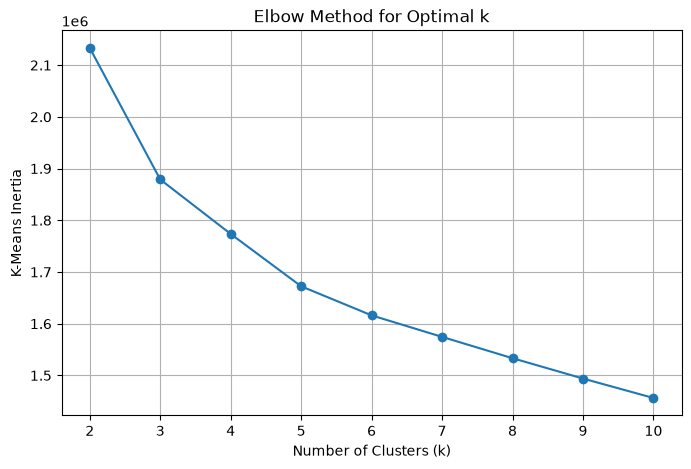

In [23]:
# Elbow Method for selecting the number of clusters

plt.figure(figsize=(8, 5))

plt.plot(
    list(inertias.keys()),
    list(inertias.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("K-Means Inertia")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [24]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for each candidate k
silhouette_scores = {}

for k, model in kmeans_models.items():
    score = silhouette_score(
        X_train_pca_reduced,
        model.labels_
    )
    silhouette_scores[k] = score

print("Silhouette scores:")

for k, score in silhouette_scores.items():
    print(f"k={k}: silhouette score={score:.4f}")

# Identify the best k based on silhouette score
best_k_silhouette = max(
    silhouette_scores,
    key=silhouette_scores.get
)

print(
    f"\nBest k based on silhouette score: "
    f"{best_k_silhouette}"
)
print(
    f"Best silhouette score: "
    f"{silhouette_scores[best_k_silhouette]:.4f}"
)

Silhouette scores:
k=2: silhouette score=0.4154
k=3: silhouette score=0.3435
k=4: silhouette score=0.1737
k=5: silhouette score=0.1425
k=6: silhouette score=0.1215
k=7: silhouette score=0.0914
k=8: silhouette score=0.0953
k=9: silhouette score=0.0899
k=10: silhouette score=0.0941

Best k based on silhouette score: 2
Best silhouette score: 0.4154


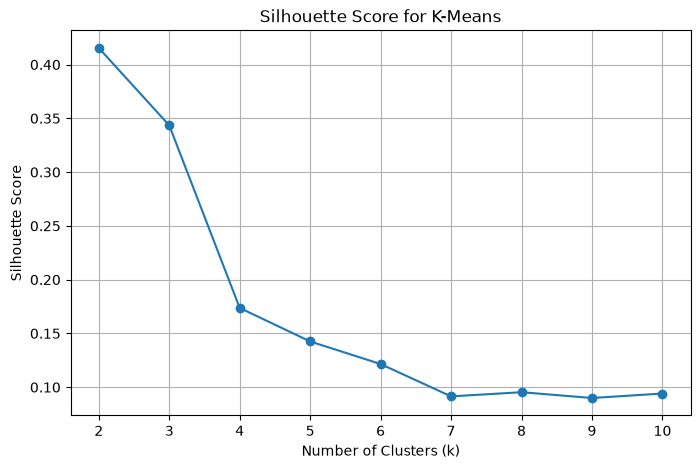

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [26]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN to the PCA-reduced training data
dbscan = DBSCAN(
    eps=3.0,
    min_samples=5,
    n_jobs=-1
)

dbscan_labels = dbscan.fit_predict(X_train_pca_reduced)

# Count clusters and noise points
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"Number of DBSCAN clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_dbscan}")
print(f"Noise percentage: {n_noise_dbscan / len(dbscan_labels) * 100:.2f}%")

Number of DBSCAN clusters: 0
Number of noise points: 7352
Noise percentage: 100.00%


In [27]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN to the PCA-reduced training data
dbscan = DBSCAN(
    eps=3.0,
    min_samples=5,
    n_jobs=-1
)

dbscan_labels = dbscan.fit_predict(X_train_pca_reduced)

# Count clusters and noise points
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"Number of DBSCAN clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_dbscan}")
print(f"Noise percentage: {n_noise_dbscan / len(dbscan_labels) * 100:.2f}%")

Number of DBSCAN clusters: 0
Number of noise points: 7352
Noise percentage: 100.00%


In [28]:
from sklearn.cluster import DBSCAN

eps_values = [3, 5, 7, 10, 15, 20]

dbscan_results = {}

for eps in eps_values:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5,
        n_jobs=-1
    )

    labels = dbscan.fit_predict(X_train_pca_reduced)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    dbscan_results[eps] = {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_percentage": n_noise / len(labels) * 100
    }

    print(
        f"eps={eps}: "
        f"clusters={n_clusters}, "
        f"noise={n_noise}, "
        f"noise%={n_noise / len(labels) * 100:.2f}%"
    )

eps=3: clusters=0, noise=7352, noise%=100.00%
eps=5: clusters=0, noise=7352, noise%=100.00%
eps=7: clusters=4, noise=7332, noise%=99.73%
eps=10: clusters=27, noise=3959, noise%=53.85%
eps=15: clusters=4, noise=716, noise%=9.74%
eps=20: clusters=2, noise=159, noise%=2.16%


In [29]:
from sklearn.metrics import silhouette_score

dbscan_silhouette_scores = {}

for eps, result in dbscan_results.items():
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5,
        n_jobs=-1
    )

    labels = dbscan.fit_predict(X_train_pca_reduced)

    # Silhouette score requires at least 2 clusters
    # and excludes noise points (-1)
    non_noise_mask = labels != -1
    filtered_labels = labels[non_noise_mask]
    filtered_data = X_train_pca_reduced[non_noise_mask]

    if len(set(filtered_labels)) >= 2:
        score = silhouette_score(
            filtered_data,
            filtered_labels
        )
        dbscan_silhouette_scores[eps] = score

        print(
            f"eps={eps}: "
            f"silhouette score={score:.4f}"
        )
    else:
        print(
            f"eps={eps}: silhouette score cannot be calculated"
        )

eps=3: silhouette score cannot be calculated
eps=5: silhouette score cannot be calculated
eps=7: silhouette score=0.3033
eps=10: silhouette score=0.1219
eps=15: silhouette score=0.0575
eps=20: silhouette score=0.4256


In [30]:
# Final DBSCAN configuration
best_dbscan = DBSCAN(
    eps=20,
    min_samples=5,
    n_jobs=-1
)

dbscan_labels = best_dbscan.fit_predict(X_train_pca_reduced)

n_clusters_dbscan = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"Final DBSCAN clusters: {n_clusters_dbscan}")
print(f"Final DBSCAN noise points: {n_noise_dbscan}")
print(
    f"Final DBSCAN noise percentage: "
    f"{n_noise_dbscan / len(dbscan_labels) * 100:.2f}%"
)
print(
    f"Final DBSCAN silhouette score: "
    f"{dbscan_silhouette_scores[20]:.4f}"
)

Final DBSCAN clusters: 2
Final DBSCAN noise points: 159
Final DBSCAN noise percentage: 2.16%
Final DBSCAN silhouette score: 0.4256


In [31]:
from sklearn.cluster import AgglomerativeClustering

# Apply hierarchical (agglomerative) clustering
hierarchical = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(
    X_train_pca_reduced
)

n_clusters_hierarchical = len(
    set(hierarchical_labels)
)

print(
    f"Number of hierarchical clusters: "
    f"{n_clusters_hierarchical}"
)

print(
    f"Cluster sizes:\n"
    f"{pd.Series(hierarchical_labels).value_counts().sort_index()}"
)

Number of hierarchical clusters: 2
Cluster sizes:
0    3286
1    4066
Name: count, dtype: int64


In [32]:
from sklearn.metrics import silhouette_score

hierarchical_silhouette = silhouette_score(
    X_train_pca_reduced,
    hierarchical_labels
)

print(
    f"Hierarchical clustering silhouette score: "
    f"{hierarchical_silhouette:.4f}"
)

Hierarchical clustering silhouette score: 0.4150


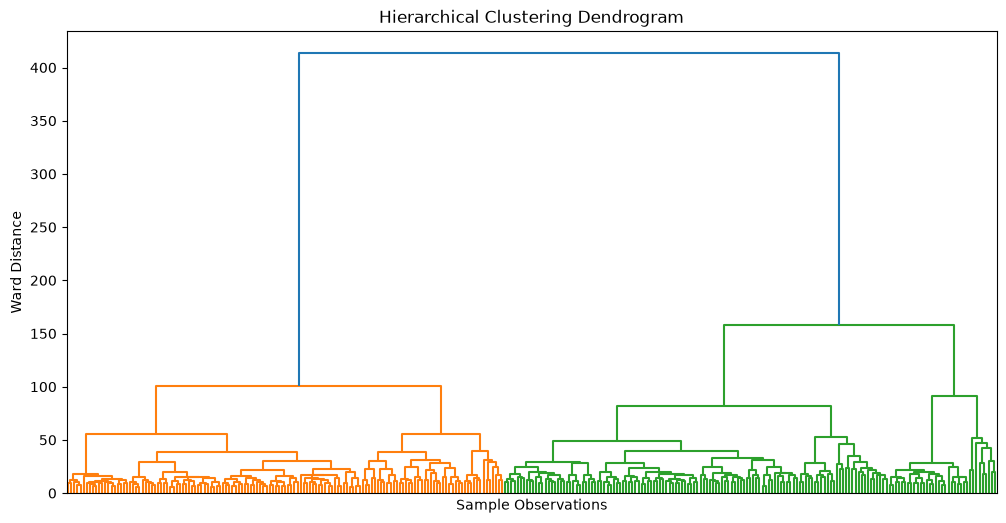

In [33]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Use a representative sample for dendrogram visualization
sample_size = 300

X_sample = X_train_pca_reduced[:sample_size]

# Compute hierarchical linkage
linkage_matrix = linkage(
    X_sample,
    method="ward"
)

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    no_labels=True,
    color_threshold=None
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Observations")
plt.ylabel("Ward Distance")

plt.show()

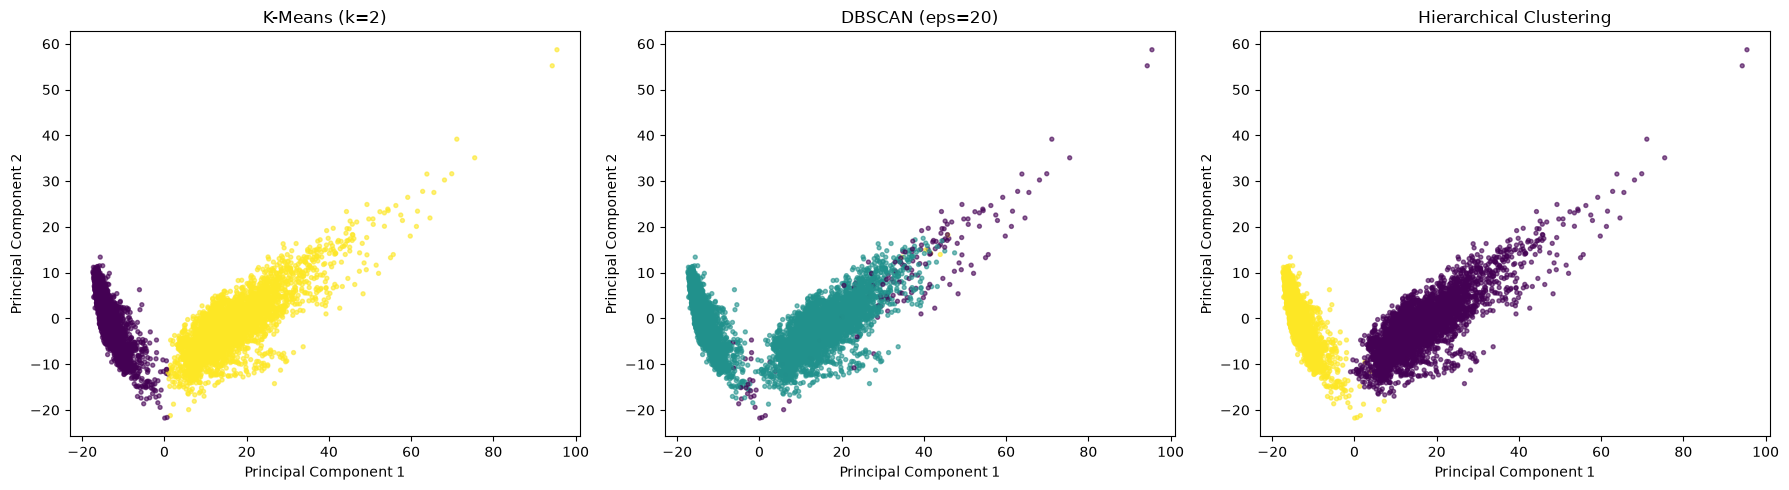

In [34]:
import matplotlib.pyplot as plt

# Use the first two principal components for visualization
X_2d = X_train_pca_reduced[:, :2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
axes[0].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=kmeans_models[2].labels_,
    s=8,
    alpha=0.6
)
axes[0].set_title("K-Means (k=2)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

# DBSCAN
axes[1].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=dbscan_labels,
    s=8,
    alpha=0.6
)
axes[1].set_title("DBSCAN (eps=20)")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

# Hierarchical
axes[2].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=hierarchical_labels,
    s=8,
    alpha=0.6
)
axes[2].set_title("Hierarchical Clustering")
axes[2].set_xlabel("Principal Component 1")
axes[2].set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

In [35]:
import plotly.express as px

# Use the first three principal components
X_3d = X_train_pca_reduced[:, :3]

# Create a DataFrame for visualization
pca_3d_df = pd.DataFrame(
    X_3d,
    columns=["PC1", "PC2", "PC3"]
)

pca_3d_df["KMeans_Cluster"] = kmeans_models[2].labels_
pca_3d_df["DBSCAN_Cluster"] = dbscan_labels
pca_3d_df["Hierarchical_Cluster"] = hierarchical_labels

# Interactive 3D visualization using K-Means clusters
fig = px.scatter_3d(
    pca_3d_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="KMeans_Cluster",
    title="3D PCA Projection with K-Means Clusters",
    opacity=0.7
)

fig.update_traces(
    marker=dict(size=3)
)

fig.show()

In [36]:
# Compare clustering methods
clustering_comparison = pd.DataFrame({
    "Method": [
        "K-Means",
        "DBSCAN",
        "Hierarchical"
    ],
    "Configuration": [
        "k=2",
        "eps=20, min_samples=5",
        "n_clusters=2, linkage=ward"
    ],
    "Clusters": [
        2,
        n_clusters_dbscan,
        n_clusters_hierarchical
    ],
    "Noise Points": [
        0,
        n_noise_dbscan,
        0
    ],
    "Silhouette Score": [
        silhouette_scores[2],
        dbscan_silhouette_scores[20],
        hierarchical_silhouette
    ]
})

clustering_comparison

,Method,Configuration,Clusters,Noise Points,Silhouette Score
0,K-Means,k=2,2,0,0.415409
1,DBSCAN,"eps=20, min_samples=5",2,159,0.425569
2,Hierarchical,"n_clusters=2, linkage=ward",2,0,0.414954


In [37]:
# Identify the best method by silhouette score
best_method = clustering_comparison.loc[
    clustering_comparison["Silhouette Score"].idxmax()
]

print("Best clustering method based on silhouette score:")
print(f"Method: {best_method['Method']}")
print(f"Configuration: {best_method['Configuration']}")
print(f"Silhouette Score: {best_method['Silhouette Score']:.4f}")

Best clustering method based on silhouette score:
Method: DBSCAN
Configuration: eps=20, min_samples=5
Silhouette Score: 0.4256


In [38]:
# Load training activity labels for post-clustering interpretation
y_train = pd.read_csv(
    DATA_DIR / "train" / "y_train.txt",
    sep=r"\s+",
    header=None,
    names=["activity_id"]
)

# Map activity IDs to activity names
y_train["activity"] = y_train["activity_id"].map(
    dict(
        zip(
            activity_labels["activity_id"],
            activity_labels["activity"]
        )
    )
)

print("Training activity labels:")
print(y_train["activity"].value_counts())

Training activity labels:
activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


In [39]:
# Combine true activity labels with clustering results
cluster_analysis = y_train.copy()

cluster_analysis["KMeans"] = kmeans_models[2].labels_
cluster_analysis["DBSCAN"] = dbscan_labels
cluster_analysis["Hierarchical"] = hierarchical_labels

# Activity distribution within each K-Means cluster
print("K-Means cluster vs activity:")
print(
    pd.crosstab(
        cluster_analysis["KMeans"],
        cluster_analysis["activity"]
    )
)

print("\nDBSCAN cluster vs activity:")
print(
    pd.crosstab(
        cluster_analysis["DBSCAN"],
        cluster_analysis["activity"]
    )
)

print("\nHierarchical cluster vs activity:")
print(
    pd.crosstab(
        cluster_analysis["Hierarchical"],
        cluster_analysis["activity"]
    )
)

K-Means cluster vs activity:
activity  LAYING  SITTING  STANDING  WALKING  WALKING_DOWNSTAIRS  \
KMeans                                                             
0           1396     1285      1374        0                   0   
1             11        1         0     1226                 986   

activity  WALKING_UPSTAIRS  
KMeans                      
0                        8  
1                     1065  

DBSCAN cluster vs activity:
activity  LAYING  SITTING  STANDING  WALKING  WALKING_DOWNSTAIRS  \
DBSCAN                                                             
-1            27        2         1       18                  97   
 0          1380     1284      1373     1208                 884   
 1             0        0         0        0                   5   

activity  WALKING_UPSTAIRS  
DBSCAN                      
-1                      14  
 0                    1059  
 1                       0  

Hierarchical cluster vs activity:
activity      LAYING  SITTING  S

In [40]:
def cluster_activity_summary(labels, method_name):
    temp = pd.DataFrame({
        "cluster": labels,
        "activity": y_train["activity"]
    })

    summary = (
        temp.groupby("cluster")["activity"]
        .value_counts(normalize=True)
        .mul(100)
        .rename("percentage")
        .reset_index()
    )

    dominant = (
        summary.sort_values(
            ["cluster", "percentage"],
            ascending=[True, False]
        )
        .groupby("cluster")
        .first()
        .reset_index()
    )

    dominant["Method"] = method_name

    return dominant[
        ["Method", "cluster", "activity", "percentage"]
    ]


kmeans_summary = cluster_activity_summary(
    kmeans_models[2].labels_,
    "K-Means"
)

dbscan_summary = cluster_activity_summary(
    dbscan_labels,
    "DBSCAN"
)

hierarchical_summary = cluster_activity_summary(
    hierarchical_labels,
    "Hierarchical"
)

activity_cluster_summary = pd.concat(
    [
        kmeans_summary,
        dbscan_summary,
        hierarchical_summary
    ],
    ignore_index=True
)

activity_cluster_summary

,Method,cluster,activity,percentage
0,K-Means,0,LAYING,34.358848
1,K-Means,1,WALKING,37.275768
2,DBSCAN,-1,WALKING_DOWNSTAIRS,61.006289
3,DBSCAN,0,LAYING,19.198664
4,DBSCAN,1,WALKING_DOWNSTAIRS,100.000000
5,Hierarchical,0,WALKING,37.309799
6,Hierarchical,1,LAYING,34.604033


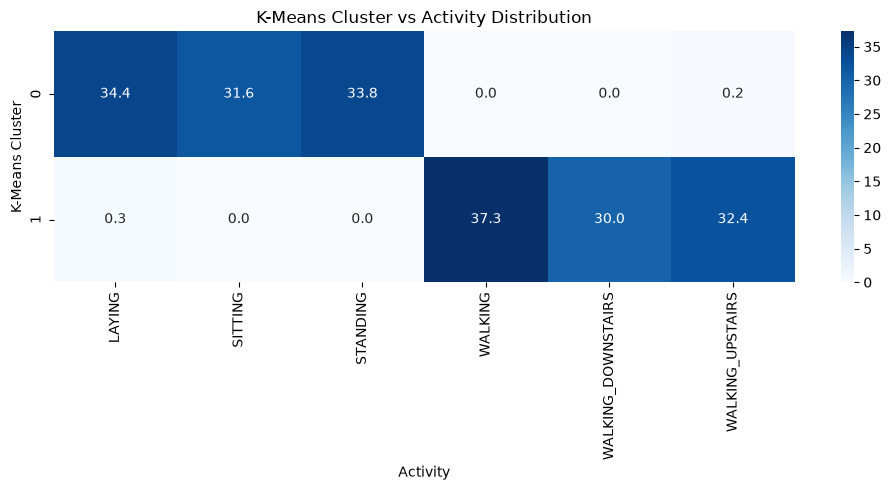

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

kmeans_activity_table = pd.crosstab(
    cluster_analysis["KMeans"],
    cluster_analysis["activity"],
    normalize="index"
) * 100

plt.figure(figsize=(10, 5))

sns.heatmap(
    kmeans_activity_table,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("K-Means Cluster vs Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("K-Means Cluster")

plt.tight_layout()
plt.show()

In [42]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [45]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

evaluation_results = []

# K-Means evaluation
kmeans_labels = kmeans_models[2].labels_

evaluation_results.append({
    "Method": "K-Means",
    "Silhouette Score": silhouette_score(
        X_train_pca_reduced,
        kmeans_labels
    ),
    "Calinski-Harabasz Score": calinski_harabasz_score(
        X_train_pca_reduced,
        kmeans_labels
    ),
    "Davies-Bouldin Score": davies_bouldin_score(
        X_train_pca_reduced,
        kmeans_labels
    )
})

# DBSCAN evaluation
dbscan_mask = dbscan_labels != -1

dbscan_data = X_train_pca_reduced[dbscan_mask]
dbscan_valid_labels = dbscan_labels[dbscan_mask]

evaluation_results.append({
    "Method": "DBSCAN",
    "Silhouette Score": silhouette_score(
        dbscan_data,
        dbscan_valid_labels
    ),
    "Calinski-Harabasz Score": calinski_harabasz_score(
        dbscan_data,
        dbscan_valid_labels
    ),
    "Davies-Bouldin Score": davies_bouldin_score(
        dbscan_data,
        dbscan_valid_labels
    )
})

# Hierarchical clustering evaluation
evaluation_results.append({
    "Method": "Hierarchical",
    "Silhouette Score": silhouette_score(
        X_train_pca_reduced,
        hierarchical_labels
    ),
    "Calinski-Harabasz Score": calinski_harabasz_score(
        X_train_pca_reduced,
        hierarchical_labels
    ),
    "Davies-Bouldin Score": davies_bouldin_score(
        X_train_pca_reduced,
        hierarchical_labels
    )
})

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Method,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,K-Means,0.415409,6161.595021,1.017109
1,DBSCAN,0.425569,25.288397,0.691455
2,Hierarchical,0.414954,6141.386430,1.018049


In [47]:
cluster_size_results = []

# K-Means
kmeans_counts = pd.Series(kmeans_labels).value_counts().sort_index()

for cluster, count in kmeans_counts.items():
    cluster_size_results.append({
        "Method": "K-Means",
        "Cluster": cluster,
        "Points": count,
        "Percentage": count / len(kmeans_labels) * 100
    })

# DBSCAN
dbscan_counts = pd.Series(dbscan_labels).value_counts().sort_index()

for cluster, count in dbscan_counts.items():
    cluster_size_results.append({
        "Method": "DBSCAN",
        "Cluster": cluster,
        "Points": count,
        "Percentage": count / len(dbscan_labels) * 100
    })

# Hierarchical
hierarchical_counts = pd.Series(
    hierarchical_labels
).value_counts().sort_index()

for cluster, count in hierarchical_counts.items():
    cluster_size_results.append({
        "Method": "Hierarchical",
        "Cluster": cluster,
        "Points": count,
        "Percentage": count / len(hierarchical_labels) * 100
    })

cluster_size_df = pd.DataFrame(cluster_size_results)

cluster_size_df

,Method,Cluster,Points,Percentage
0,K-Means,0,4063,55.263874
1,K-Means,1,3289,44.736126
2,DBSCAN,-1,159,2.162677
3,DBSCAN,0,7188,97.769314
4,DBSCAN,1,5,0.068009
5,Hierarchical,0,3286,44.695321
6,Hierarchical,1,4066,55.304679


In [48]:
kmeans_activity_distribution = (
    pd.crosstab(
        cluster_analysis["KMeans"],
        cluster_analysis["activity"],
        normalize="index"
    ) * 100
).round(2)

print("K-Means Cluster Activity Distribution (%)")
kmeans_activity_distribution

K-Means Cluster Activity Distribution (%)


activity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
KMeans,,,,,,
0,34.36,31.63,33.82,0.00,0.00,0.20
1,0.33,0.03,0.00,37.28,29.98,32.38


In [49]:
dbscan_activity_distribution = (
    pd.crosstab(
        cluster_analysis["DBSCAN"],
        cluster_analysis["activity"],
        normalize="index"
    ) * 100
).round(2)

print("DBSCAN Cluster Activity Distribution (%)")
dbscan_activity_distribution

DBSCAN Cluster Activity Distribution (%)


activity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
DBSCAN,,,,,,
-1,16.98,1.26,0.63,11.32,61.01,8.81
0,19.20,17.86,19.10,16.81,12.30,14.73
1,0.00,0.00,0.00,0.00,100.00,0.00


In [50]:
hierarchical_activity_distribution = (
    pd.crosstab(
        cluster_analysis["Hierarchical"],
        cluster_analysis["activity"],
        normalize="index"
    ) * 100
).round(2)

print("Hierarchical Cluster Activity Distribution (%)")
hierarchical_activity_distribution

Hierarchical Cluster Activity Distribution (%)


activity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
Hierarchical,,,,,,
0,0.0,0.03,0.00,37.31,30.01,32.65
1,34.6,31.60,33.79,0.00,0.00,0.00


In [51]:
# Predict test-set clusters using the fitted K-Means model
kmeans_test_labels = kmeans_models[2].predict(X_test_pca_reduced)

test_cluster_counts = (
    pd.Series(kmeans_test_labels)
    .value_counts()
    .sort_index()
)

test_cluster_distribution = pd.DataFrame({
    "Cluster": test_cluster_counts.index,
    "Test Points": test_cluster_counts.values,
    "Percentage": (
        test_cluster_counts.values /
        len(kmeans_test_labels) * 100
    ).round(2)
})

test_cluster_distribution

,Cluster,Test Points,Percentage
0,0,1560,52.94
1,1,1387,47.06


In [52]:
print("PCA Transformation Consistency Check")
print("=" * 45)

print(f"Training data shape: {X_train_pca_reduced.shape}")
print(f"Test data shape: {X_test_pca_reduced.shape}")

print(f"Number of PCA components: {n_components}")

print(
    f"Training variance retained: "
    f"{pca.explained_variance_ratio_[:n_components].sum():.4f}"
)

print(
    f"Test data transformed using same PCA model: "
    f"{X_test_pca_reduced.shape[1] == n_components}"
)

assert X_train_pca_reduced.shape[1] == n_components
assert X_test_pca_reduced.shape[1] == n_components

print("\nPCA transformation check passed.")

PCA Transformation Consistency Check
Training data shape: (7352, 102)
Test data shape: (2947, 102)
Number of PCA components: 102
Training variance retained: 0.9508
Test data transformed using same PCA model: True

PCA transformation check passed.


## Final Findings and Conclusion

### Methodology Summary

The analysis followed a reproducible unsupervised learning pipeline:

1. Loaded the UCI Human Activity Recognition Using Smartphones dataset.
2. Validated the dataset structure, dimensions, feature names, and missing values.
3. Resolved duplicate feature names while preserving all 561 original features.
4. Standardized the numerical features using `StandardScaler`.
5. Applied Principal Component Analysis (PCA) to reduce dimensionality while preserving approximately 95% of the variance.
6. Evaluated K-Means clustering across multiple values of `k` using the Elbow Method and Silhouette Score.
7. Applied DBSCAN and evaluated different `eps` values while accounting for noise observations.
8. Applied Agglomerative Hierarchical Clustering using Ward linkage.
9. Compared clustering methods using Silhouette, Calinski-Harabasz, and Davies-Bouldin scores.
10. Visualized the resulting clusters using 2D PCA projections, a hierarchical dendrogram, and an interactive 3D PCA visualization.
11. Used the known activity labels only after clustering for post-hoc interpretation of the discovered cluster structure.

### Key Findings

- PCA reduced the original 561-dimensional feature space to 102 principal components while retaining approximately 95% of the variance.
- K-Means achieved its highest Silhouette Score at `k=2`, with a score of approximately `0.4154`.
- DBSCAN achieved its strongest evaluated configuration at `eps=20` and `min_samples=5`, producing 2 clusters with approximately 2.16% of observations classified as noise.
- DBSCAN achieved the highest Silhouette Score among the evaluated clustering methods, approximately `0.4256`.
- Hierarchical clustering with 2 clusters achieved a Silhouette Score of approximately `0.4150`.
- Post-hoc comparison with the known activity labels showed that K-Means discovered a meaningful broad separation between stationary activities such as laying, sitting, and standing and dynamic walking activities.
- The clustering results demonstrate that dimensionality reduction can reveal meaningful structure in high-dimensional smartphone sensor data without using activity labels during model fitting.

### Conclusion

The results indicate that PCA combined with unsupervised clustering can reveal meaningful structure within high-dimensional human activity sensor data. Although the clustering methods do not perfectly recover all six predefined activities, they successfully identify broader activity patterns, particularly the distinction between stationary and movement-related observations.

Among the evaluated configurations, DBSCAN produced the highest Silhouette Score, while K-Means provided a particularly interpretable two-cluster structure. These results demonstrate the usefulness of combining dimensionality reduction with multiple unsupervised clustering techniques for exploratory analysis of high-dimensional sensor data.

In [53]:
model_selection_summary = evaluation_df.copy()

model_selection_summary["Silhouette Rank"] = (
    model_selection_summary["Silhouette Score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

model_selection_summary["Calinski-Harabasz Rank"] = (
    model_selection_summary["Calinski-Harabasz Score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

model_selection_summary["Davies-Bouldin Rank"] = (
    model_selection_summary["Davies-Bouldin Score"]
    .rank(ascending=True, method="min")
    .astype(int)
)

model_selection_summary

,Method,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score,Silhouette Rank,Calinski-Harabasz Rank,Davies-Bouldin Rank
0,K-Means,0.415409,6161.595021,1.017109,2,1,2
1,DBSCAN,0.425569,25.288397,0.691455,1,3,1
2,Hierarchical,0.414954,6141.386430,1.018049,3,2,3


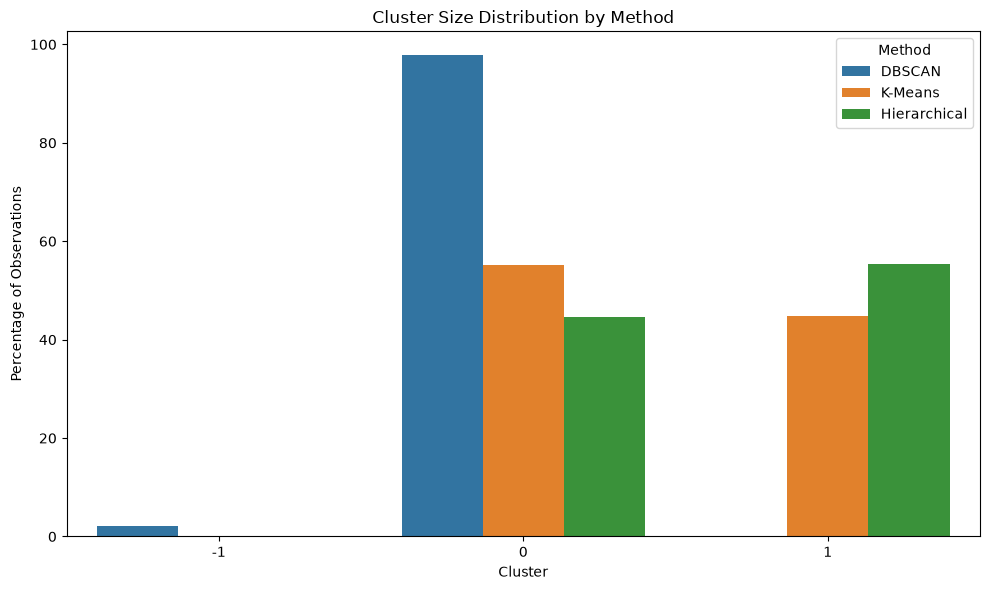

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cluster_size_df,
    x="Cluster",
    y="Percentage",
    hue="Method"
)

plt.title("Cluster Size Distribution by Method")
plt.xlabel("Cluster")
plt.ylabel("Percentage of Observations")
plt.legend(title="Method")

plt.tight_layout()
plt.show()

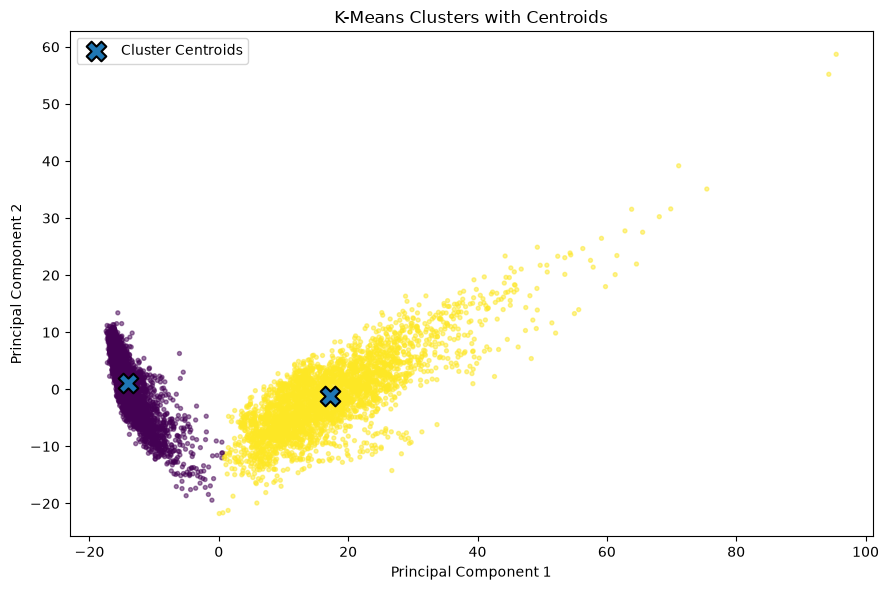

In [55]:
kmeans_2d = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_2d.fit(X_train_pca_reduced[:, :2])

kmeans_2d_labels = kmeans_2d.labels_
kmeans_2d_centers = kmeans_2d.cluster_centers_

plt.figure(figsize=(9, 6))

plt.scatter(
    X_train_pca_reduced[:, 0],
    X_train_pca_reduced[:, 1],
    c=kmeans_2d_labels,
    s=8,
    alpha=0.5
)

plt.scatter(
    kmeans_2d_centers[:, 0],
    kmeans_2d_centers[:, 1],
    marker="X",
    s=200,
    edgecolor="black",
    linewidth=1.5,
    label="Cluster Centroids"
)

plt.title("K-Means Clusters with Centroids")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.tight_layout()
plt.show()

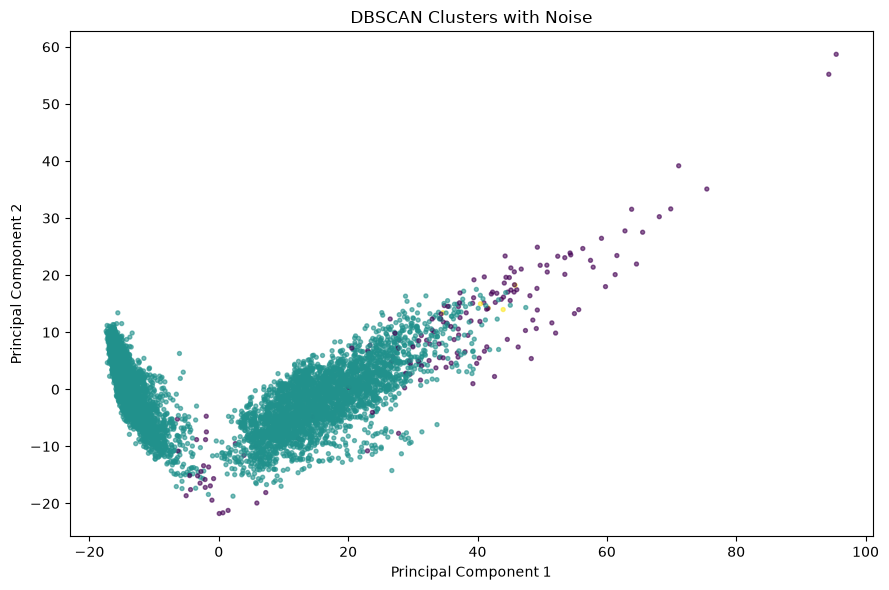

In [56]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_train_pca_reduced[:, 0],
    X_train_pca_reduced[:, 1],
    c=dbscan_labels,
    s=8,
    alpha=0.6
)

plt.title("DBSCAN Clusters with Noise")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

## Reproducibility Configuration

The analysis uses fixed parameters and random seeds to make the results reproducible.

- Standardization: `StandardScaler`
- PCA variance target: approximately 95%
- K-Means: `k=2`, `random_state=42`, `n_init=10`
- DBSCAN: `eps=20`, `min_samples=5`
- Hierarchical clustering: `n_clusters=2`, `linkage="ward"`
- PCA components used for clustering: `102`

## Limitations

- The clustering algorithms were evaluated on the training portion of the dataset.
- The known activity labels were used only for post-hoc interpretation and were not provided to the clustering algorithms.
- PCA retains approximately 95% of the variance, so some information from the original 561-dimensional feature space is discarded.
- DBSCAN performance is sensitive to parameters such as `eps` and `min_samples`.
- The hierarchical clustering dendrogram uses a representative sample of 300 observations because generating a dendrogram for all observations would be difficult to interpret.
- The discovered clusters do not necessarily correspond exactly to the six predefined human activities; they represent structure discovered by the unsupervised algorithms.

In [57]:
best_model = evaluation_df.loc[
    evaluation_df["Silhouette Score"].idxmax()
]

print("Final Model Selection")
print("=" * 40)
print(f"Best method: {best_model['Method']}")
print(f"Silhouette Score: {best_model['Silhouette Score']:.4f}")
print(
    f"Calinski-Harabasz Score: "
    f"{best_model['Calinski-Harabasz Score']:.2f}"
)
print(
    f"Davies-Bouldin Score: "
    f"{best_model['Davies-Bouldin Score']:.4f}"
)

Final Model Selection
Best method: DBSCAN
Silhouette Score: 0.4256
Calinski-Harabasz Score: 25.29
Davies-Bouldin Score: 0.6915


### Model Selection Interpretation

Based on the evaluated internal clustering metrics, DBSCAN with `eps=20` and `min_samples=5` provides the strongest overall clustering structure according to the Silhouette Score. However, K-Means provides a more interpretable broad separation between stationary and movement-related activities.

Therefore, DBSCAN is selected as the best-performing configuration by internal validation, while K-Means is retained as an important complementary interpretation of the activity structure.